## TASK-8

## INLAB

## TASK-1

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

# Prevent copy warnings using an explicit copy
X_pima = pima_df[pima_cols[:-1]].copy()
y_pima = pima_df['Outcome']

# Mark invalid zeros as NaN placeholders for imputation
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_pima[cols_to_impute] = X_pima[cols_to_impute].replace(0, np.nan)

# Impute and standardize
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_pima)

scaler = StandardScaler()
X_pima_scaled = scaler.fit_transform(X_imputed)

# Stratified train-test split
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima_scaled, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

print("Preprocessed Pima dataset shapes:")
print(f"  Training set features: {X_train_p.shape} | Test set features: {X_test_p.shape}")


Preprocessed Pima dataset shapes:
  Training set features: (614, 8) | Test set features: (154, 8)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Design baseline sequential model
ann_pima = Sequential([
    # Input layer + Hidden layer 1: 16 neurons with ReLU activation
    Dense(16, activation='relu', input_shape=(8,)),
    # Hidden layer 2: 8 neurons with ReLU activation
    Dense(8, activation='relu'),
    # Output layer: 1 neuron with Sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

print("Sequential ANN Architecture established:")
ann_pima.summary()


Sequential ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense (Dense)                 │ (None, 16)            │          144 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 8)             │          136 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 1)             │            9 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the neural network model
ann_pima.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Neural network model compiled successfully.")

Neural network model compiled successfully.


In [7]:
# Fit model and collect training metrics
history_pima = ann_pima.fit(
    X_train_p, 
    y_train_p, 
    epochs=50, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1
)

print("\nModel training complete.")

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6823 - loss: 0.5802 - val_accuracy: 0.6748 - val_loss: 0.5782
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7006 - loss: 0.5490 - val_accuracy: 0.6829 - val_loss: 0.5527
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7128 - loss: 0.5276 - val_accuracy: 0.7073 - val_loss: 0.5351
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7271 - loss: 0.5132 - val_accuracy: 0.7236 - val_loss: 0.5197
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7393 - loss: 0.5014 - val_accuracy: 0.7317 - val_loss: 0.5090
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7536 - loss: 0.4913 - val_accuracy: 0.7398 - val_loss: 0.4991
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7576 - loss: 0.4838 - val_accuracy: 0.7561 - val_loss: 0.4914
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7678 - loss: 0.4766 - val_accuracy: 0.7642 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
ANN Holdout Test Accuracy: 73.38%

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.77      0.84      0.80       100
    Diabetes       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



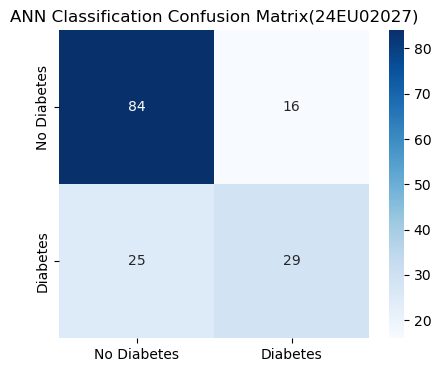

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predict target probabilities
y_pred_probs = ann_pima.predict(X_test_p)
# Threshold probabilities to binary classes (0 or 1)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

test_acc = accuracy_score(y_test_p, y_pred_classes)
print(f"ANN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test_p, y_pred_classes, target_names=['No Diabetes', 'Diabetes']))

# Plot confusion matrix
cm_pima = confusion_matrix(y_test_p, y_pred_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pima, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.title("ANN Classification Confusion Matrix(24EU02027)")
plt.show()


## TASK-2

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]
y_sonar = sonar_df['Class_numeric']

# Scale features
scaler_sonar = StandardScaler()
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

# Split into train/test sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Design regularized sequential network
ann_sonar = Sequential([
    # Input layer + Dense hidden layer 1
    Dense(64, activation='relu', input_shape=(60,)),
    Dropout(0.3), # Apply 30% dropout rate to mitigate co-adaptation
    # Dense hidden layer 2
    Dense(32, activation='relu'),
    Dropout(0.3), # Apply 30% dropout rate
    # Binary sigmoid output node
    Dense(1, activation='sigmoid')
])

print("Regularized Sonar ANN Architecture established:")
ann_sonar.summary()


Regularized Sonar ANN Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_3 (Dense)               │ (None, 64)            │        3,904 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 64)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_4 (Dense)               │ (None, 32)            │        2,080 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ (None, 32)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_5 (Dense)               │ (None, 1)             │           33 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model
ann_sonar.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fit model and collect training metrics
history_sonar = ann_sonar.fit(
    X_train_s, 
    y_train_s, 
    epochs=80, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1
)

print("\nModel training complete.")

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5172 - loss: 0.7777 - val_accuracy: 0.4828 - val_loss: 0.7344
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5862 - loss: 0.7185 - val_accuracy: 0.5862 - val_loss: 0.6736
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5862 - loss: 0.6781 - val_accuracy: 0.7586 - val_loss: 0.6276
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6897 - loss: 0.5854 - val_accuracy: 0.6897 - val_loss: 0.5910
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6983 - loss: 0.5831 - val_accuracy: 0.7586 - val_loss: 0.5672
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7672 - loss: 0.4938 - val_accuracy: 0.7586 - val_loss: 0.5438
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8017 - loss: 0.4669 - val_accuracy: 0.7586 - val_loss: 0.5142
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8362 - loss: 0.4289 - val_accuracy: 0.7586 - val_loss: 0.4892


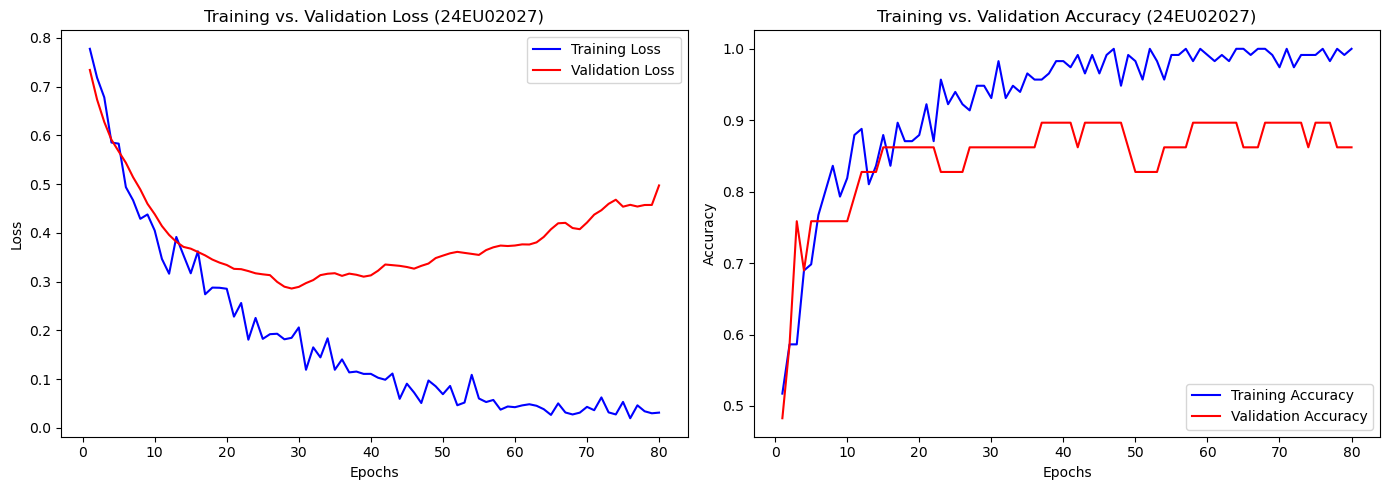

In [12]:
import matplotlib.pyplot as plt

# Extract metrics from training history
train_loss = history_sonar.history['loss']
val_loss = history_sonar.history['val_loss']
train_acc = history_sonar.history['accuracy']
val_acc = history_sonar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, 'b-', label='Training Loss')
axes[0].plot(epochs_range, val_loss, 'r-', label='Validation Loss')
axes[0].set_title("Training vs. Validation Loss (24EU02027)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot accuracy curves
axes[1].plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
axes[1].set_title("Training vs. Validation Accuracy (24EU02027)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
--- Classification Report (Sonar Test Set) ---
              precision    recall  f1-score   support

    Rock (0)       0.82      0.93      0.87        29
    Mine (1)       0.93      0.82      0.88        34

    accuracy                           0.87        63
   macro avg       0.88      0.88      0.87        63
weighted avg       0.88      0.87      0.87        63



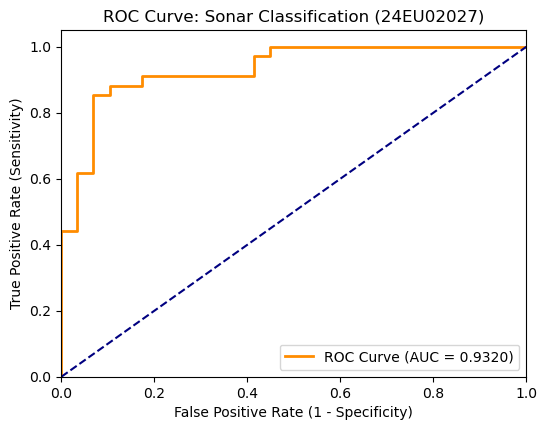

In [13]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities on test set
sonar_probs = ann_sonar.predict(X_test_s)[:, 0]
sonar_preds = (sonar_probs >= 0.5).astype(int)

# Print classification report
print("--- Classification Report (Sonar Test Set) ---")
print(classification_report(y_test_s, sonar_preds, target_names=['Rock (0)', 'Mine (1)']))

# Compute ROC curve coordinates and AUC score
fpr, tpr, _ = roc_curve(y_test_s, sonar_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve: Sonar Classification (24EU02027)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()

## TASK-3

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define parameterized builder function
def build_ann_model(optimizer_name='adam'):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(8,)),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizer_name, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

print("Modular ANN model builder function established.")

Modular ANN model builder function established.


In [15]:
optimizers = ['adam', 'sgd', 'rmsprop']
history_records = {}

print("--- Running Optimizer Search ---")
for opt in optimizers:
    print(f"Training network using: {opt}...")
    temp_model = build_ann_model(optimizer_name=opt)
    
    # Fit for 30 epochs
    hist = temp_model.fit(
        X_train_p, 
        y_train_p, 
        validation_split=0.2, 
        epochs=30, 
        batch_size=16, 
        verbose=0
    )
    history_records[opt] = hist.history['loss']

print("Tuning loop complete.")

--- Running Optimizer Search ---
Training network using: adam...
Training network using: sgd...
Training network using: rmsprop...
Tuning loop complete.


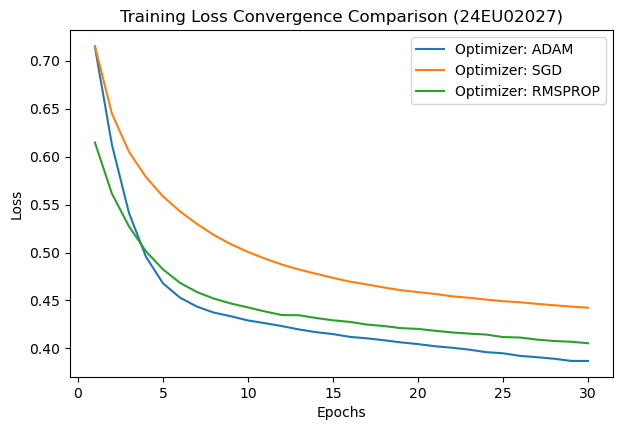

In [16]:
import matplotlib.pyplot as plt

# Plot optimizer training loss profiles
plt.figure(figsize=(7, 4.5))
for opt in optimizers:
    plt.plot(range(1, 31), history_records[opt], label=f"Optimizer: {opt.upper()}")

plt.title("Training Loss Convergence Comparison (24EU02027)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# Build model with the optimal optimizer found
tuned_model = build_ann_model(optimizer_name='adam')

print("Training model with Early Stopping...")
# Fit model for up to 100 epochs
history_tuned = tuned_model.fit(
    X_train_p, 
    y_train_p, 
    validation_split=0.2, 
    epochs=100, 
    batch_size=16, 
    callbacks=[early_stop], 
    verbose=1
)

Training model with Early Stopping...
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5214 - loss: 0.7066 - val_accuracy: 0.6423 - val_loss: 0.6447
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6843 - loss: 0.6103 - val_accuracy: 0.7480 - val_loss: 0.5728
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7169 - loss: 0.5497 - val_accuracy: 0.7724 - val_loss: 0.5253
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7352 - loss: 0.5120 - val_accuracy: 0.7642 - val_loss: 0.4975
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7495 - loss: 0.4869 - val_accuracy: 0.7724 - val_loss: 0.4800
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7617 - loss: 0.4713 - val_accuracy: 0.7805 - val_loss: 0.4680
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7617 - loss: 0.4581 - val_accuracy: 0.7805 - val_loss: 0.4602
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7760 - 

In [18]:
from sklearn.metrics import accuracy_score

# Evaluate baseline model from Task 1
baseline_accuracy = ann_pima.evaluate(X_test_p, y_test_p, verbose=0)[1]

# Evaluate the tuned, early-stopped model
tuned_accuracy = tuned_model.evaluate(X_test_p, y_test_p, verbose=0)[1]

comparison_df = pd.DataFrame({
    'Model Configuration': ['Baseline ANN (Fixed 50 Epochs)', 'Tuned ANN (with Early Stopping)'],
    'Test Accuracy (%)': [baseline_accuracy * 100, tuned_accuracy * 100],
    'Epochs Trained': [50, len(history_tuned.history['loss'])]
})

print("--- Final Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Final Performance Comparison ---
            Model Configuration  Test Accuracy (%)  Epochs Trained
 Baseline ANN (Fixed 50 Epochs)          73.376626              50
Tuned ANN (with Early Stopping)          75.974023              39


## POSTLAB

Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_18 (Dense)              │ (None, 16)            │          112 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_19 (Dense)              │ (None, 8)             │          136 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_20 (Dense)              │ (None, 1)             │            9 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6046 - loss: 0.6720 - val_accuracy: 0.6783 - val_loss: 0.6376
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7557 - loss: 0.5719 - val_accuracy: 0.7203 - val_loss: 0.5698
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7821 - loss: 0.5122 - val_accuracy: 0.7413 - val_loss: 0.5337
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7944 - loss: 0.4780 - val_accuracy: 0.7762 - val_loss: 0.5124
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8032 - loss: 0.4554 - val_accuracy: 0.7692 - val_loss: 0.5012
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8049 - loss: 0.4408 - val_accuracy: 0.7762 - val_loss: 0.4933
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8032 - loss: 0.4300 - val_accuracy: 0.7762 - val_loss: 0.4894
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8049 - loss: 0.4217 - val_accuracy: 0.7762 - val_los

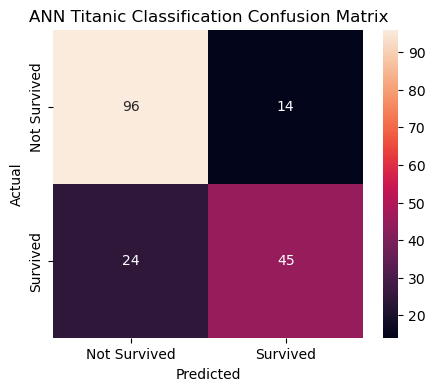

In [19]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load Titanic Dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(titanic_url)

print("Dataset Shape:", df.shape)
print(df.head())

# Select useful features
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
y = df['Survived']

# Convert Sex into numeric values
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

# Build ANN model
ann_titanic = Sequential([
    Dense(16, activation='relu', input_shape=(6,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Display model
ann_titanic.summary()

# Compile model
ann_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history_titanic = ann_titanic.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("Model training completed.")

# Predict
y_pred_prob = ann_titanic.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nANN Test Accuracy:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Not Survived', 'Survived']
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Titanic Classification Confusion Matrix")
plt.show()